# QuVINE on the CD4-vs-CD8 cell graph — a few-shot "centroid seed" study

Uses QuVINE (Quantum View-based Network Embeddings) on `pbmc5k_small_cd4_vs_cd8.h5ad`
— 500 cells, two view-graphs (`rna_connectivities`, `protein_connectivities`), with
`graph_seed` / `graph_eval` splits.

**Why this vehicle, and why few-shot.** The earlier T-vs-monocyte task *saturated*: those
cell types are so separable that raw logistic regression on the node features alone hits
macro-F1 ≈ 1.0 with **no graph at all**, and centroid ranking recovered the whole class
perfectly (recall@k was exactly `k/|targets|` for every method). A task the features already
solve cannot discriminate graph-embedding methods. We fix this two ways:

1. **Harder task** — CD4 vs CD8. Both are T cells, so the classes are close (raw-LR only
   ≈0.95–0.97), leaving real headroom.
2. **Few-shot seeding** — we keep the seed **centroid** as the ranking anchor but shrink the
   number of *labeled* seeds per class to `k` and **sweep `k`**. With few anchors the centroid
   is noisy, so recovery must lean on the embedding's structural spread — exactly where a
   quantum walk can beat a classical one. This is the "centroid seed" study: performance as a
   function of how many seeds seed the centroid.

**Two complementary evals, both run few-shot (same `k`-seed subset drives every arm):**

1. **Node classification** — LR trained on the `k` seed-node embeddings, predict eval.
   Includes a native **graph label-spreading** baseline that diffuses a soft-seed matrix over
   the graph (no embedding). Reported as a *curve vs `k`*.
2. **Node ranking (centroid seed → target)** — rank non-seed nodes by cosine similarity to the
   `k`-seed **centroid** (`seed_centroid_scores`) and measure same-class eval recovery
   (recall@K / precision@K) against **degree- and distance-matched null controls**
   (`SeedTargetEvaluator`). This is the headline: the quantum walk directly, no downstream
   classifier.

**Views.** RNA-graph and protein-graph, embedded separately and as an early-fusion concat.

**A subtlety worth stating:** QuVINE's `embed(..., seeds=...)` uses `seeds` as *structural,
label-free calibration* anchors for the quantum walk. We calibrate on the full `graph_seed`
node set once (identities only — no class labels leak), then vary only the *labeled* seeds used
downstream. So the embeddings are fixed across the sweep; only the label budget shrinks.

---

**Install.** QuVINE ships behind an optional extra, so a plain `pip install qbiocode`
does *not* pull its dependencies (gensim, hiperwalk, node2vec, torch-geometric,
python-louvain, ripser, omegaconf). Install it with:

```bash
pip install "qbiocode[quvine]"
```

Calling a `quvine_*` method without the extra raises an error naming the missing
package and this exact command, rather than a bare `ModuleNotFoundError`.

This notebook also reads an `.h5ad` fixture, so it needs `anndata` — part of the
base install.


## 1. Configuration

In [1]:
# ============================ CONFIG ============================
QUICK = False  # False = full training budget (fair to the quantum walks); slower (~5-10 min).
               # Set True for a quick laptop demo. Either way QW_STEPS (below) controls the
               # quantum-walk regime, which is the parameter that actually matters here.

TASK = "binary_cd4_vs_cd8"     # harder vehicle: CD4 vs CD8 (both T cells -> close)
METHODS = ["node2vec", "quvine_rwr", "quvine_ctqw", "quvine_dtqw"]
#   node2vec         : PURE classical baseline (DeepWalk-style) -- the honest classical yardstick
#   quvine_rwr       : QuVINE SGNS on a CLASSICAL random-walk-with-restart view -> ABLATION
#                      (same pipeline as the quantum arms, only the walk is classical);
#                      NOT "the classical baseline" -- it is a hybrid control.
#   quvine_ctqw/dtqw : QuVINE SGNS on continuous/discrete-time QUANTUM walk views
VIEWS = ["rna", "protein"]     # modality graphs to embed (and an early-fusion concat)
EVAL_MODE = "both"             # "classification" | "ranking" | "both"
N_REPEATS = 3                  # embedding seeds -> confidence intervals over the embedding
K_VALUES = [20, 50, 100]       # recall@K / precision@K retrieval cutoffs

# --- few-shot "centroid seed" sweep ---------------------------------------------
# Keep the seed CENTROID as the ranking anchor, but shrink the number of LABELED
# seeds per class to k_seeds and sweep it. Few anchors -> noisy centroid -> recovery
# leans on the embedding's structural spread (where quantum walks can separate).
# The SAME k-seed subset drives the ranking centroid, the LR classifier, and the
# diffusion baseline, so all arms see the same label budget.
SEEDS_PER_CLASS = [1, 3, 5, 10, 25]   # few-shot k (auto-clipped to available seeds/class)
N_SUBSAMPLE = 3                        # random seed draws per k -> CIs over the draw
K_HEADLINE = 50                        # retrieval cutoff shown in the sweep curves

# --- quantum-walk regime (the parameter that matters) ---------------------------
# QW_STEPS = ctqw evolution time / dtqw coined-step count. Continuous- and discrete-time
# quantum walks spread BALLISTICALLY, so LARGE step counts over-mix: the walk relaxes
# toward its stationary distribution and same-class neighborhood structure is washed out
# (we verified this -- raising steps 10->30 widened the quantum deficit). We therefore keep
# the walk SMALL / localized. Classical node2vec & quvine_rwr ignore `steps` (they use
# num_walks/walk_length), so this choice tunes only the quantum arms -- it does not
# handicap the classical baseline.
QW_STEPS = 4

# QuVINE embedding knobs. Walk/training budget applied EQUALLY to every method; only the
# quantum arms consume QW_STEPS.
QUVINE_OVERRIDES = (
    {"views": {"num_views": 2}, "walks": {"num_walks": 5, "walk_length": 6, "steps": QW_STEPS},
     "train": {"epochs": 20, "workers": 1}, "workers": 1, "dimension": 32}
    if QUICK else
    {"views": {"num_views": 2}, "walks": {"num_walks": 10, "walk_length": 10, "steps": QW_STEPS},
     "train": {"epochs": 50, "workers": 1}, "workers": 1, "dimension": 64}
)
print("QUICK:", QUICK, "| task:", TASK, "| methods:", METHODS, "| views:", VIEWS)
print("few-shot seeds/class:", SEEDS_PER_CLASS, "| subsamples:", N_SUBSAMPLE,
      "| eval:", EVAL_MODE, "| emb repeats:", N_REPEATS, "| QW_STEPS:", QW_STEPS)
print("QuVINE overrides:", QUVINE_OVERRIDES)

QUICK: False | task: binary_cd4_vs_cd8 | methods: ['node2vec', 'quvine_rwr', 'quvine_ctqw', 'quvine_dtqw'] | views: ['rna', 'protein']
few-shot seeds/class: [1, 3, 5, 10, 25] | subsamples: 3 | eval: both | emb repeats: 3 | QW_STEPS: 4
QuVINE overrides: {'views': {'num_views': 2}, 'walks': {'num_walks': 10, 'walk_length': 10, 'steps': 4}, 'train': {'epochs': 50, 'workers': 1}, 'workers': 1, 'dimension': 64}


## 2. Imports & data

In [2]:
import warnings, time, os
warnings.filterwarnings("ignore")
os.environ.setdefault("OMP_NUM_THREADS", "1")
import numpy as np, pandas as pd, networkx as nx, anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

from qbiocode.apps.quvine import embed
from qbiocode.apps.quvine.evaluation.ranking import SeedTargetEvaluator, seed_centroid_scores
from qbiocode.utils import tutorial_data_path
sns.set_style("whitegrid")

# ---- Data path ----
# tutorial_data_path() is QBioCode's single resolution path for tutorial fixtures. It
# searches $QBC_DATA first, then every fixture directory of a source checkout -- located
# both from the installed package and by walking up from this notebook's directory, so it
# works for an editable install and for a normal install used inside a clone -- and raises
# a FileNotFoundError naming every directory it tried. Fixtures shared between tutorials
# are committed once and found from either tree.
H5AD = tutorial_data_path("pbmc5k_small_cd4_vs_cd8.h5ad")
adata = ad.read_h5ad(H5AD)

N = adata.n_obs
IDS = [f"c{i}" for i in range(N)]                       # STRING node ids (required by QuVINE SGNS)

# This "small" file has no precomputed label_int / Y_soft / class_order — reconstruct them.
lab = adata.obs[TASK].astype(str)
CLASS_ORDER = sorted(lab.unique())                      # e.g. ['CD4_T', 'CD8_T']
lab2i = {c: i for i, c in enumerate(CLASS_ORDER)}
y = lab.map(lab2i).to_numpy().astype(int)               # 0/1 aligned to CLASS_ORDER
seed_m = adata.obs["graph_seed"].to_numpy().astype(bool)
eval_m = adata.obs["graph_eval"].to_numpy().astype(bool)

# Soft-label matrix for the diffusion baseline: soft one-hot (alpha) on seeds, uniform on eval.
# (label_spread zeroes the eval rows before propagating, so only the seed rows matter.)
ALPHA = 0.9
Y_soft = np.full((N, len(CLASS_ORDER)), 1.0 / len(CLASS_ORDER), dtype=float)
Y_soft[seed_m] = 0.0
Y_soft[np.where(seed_m)[0], y[seed_m]] = ALPHA

def to_graph(adj):
    adj = adj.tocoo(); G = nx.Graph(); G.add_nodes_from(IDS)
    for i, j, w in zip(adj.row, adj.col, adj.data):
        if i < j:
            G.add_edge(IDS[i], IDS[j], weight=float(w))
    return G

GRAPHS = {v: to_graph(adata.obsp[f"{v}_connectivities"]) for v in VIEWS}
ADJ = {v: adata.obsp[f"{v}_connectivities"].tocsr().astype(float) for v in VIEWS}
seed_nodes = [IDS[i] for i in np.where(seed_m)[0]]      # calibration anchors (identities only)

# Per-class seed pools for the few-shot sweep; clip requested k to what's available.
seed_pool = {c: np.where(seed_m & (y == c))[0] for c in range(len(CLASS_ORDER))}
max_k = min(len(p) for p in seed_pool.values())
SEEDS_PER_CLASS = [k for k in SEEDS_PER_CLASS if k <= max_k]

print(f"{N} nodes | classes {CLASS_ORDER} | seeds {seed_m.sum()} eval {eval_m.sum()}")
for c, cn in enumerate(CLASS_ORDER):
    print(f"  {cn}: seed_pool={len(seed_pool[c])} eval={(eval_m & (y == c)).sum()}")
print(f"  few-shot k (clipped, max={max_k}): {SEEDS_PER_CLASS}")
for v in VIEWS:
    print(f"  {v} graph: {GRAPHS[v].number_of_nodes()} nodes, {GRAPHS[v].number_of_edges()} edges")

500 nodes | classes ['CD4_T', 'CD8_T'] | seeds 143 eval 357
  CD4_T: seed_pool=76 eval=174
  CD8_T: seed_pool=67 eval=183
  few-shot k (clipped, max=67): [1, 3, 5, 10, 25]
  rna graph: 500 nodes, 5141 edges
  protein graph: 500 nodes, 5470 edges


## 3. Compute QuVINE embeddings

Each method is embedded on each view graph, for `N_REPEATS` seeds. Calibration seeds are our
labeled seed nodes. An early-fusion **`concat`** view (RNA ⊕ protein, standardized) is added.

In [3]:
def embed_view(method, view, base_seed):
    r = embed(GRAPHS[view], method, seeds=seed_nodes, base_seed=base_seed,
              overrides=QUVINE_OVERRIDES, verbose=False)
    # rows already align to IDS order (graph built with add_nodes_from(IDS))
    return np.asarray(r.embedding, dtype=float)

# EMB[(method, view, seed)] -> (N, d)
EMB = {}
t_all = time.time()
for method in METHODS:
    for seed in range(N_REPEATS):
        parts = {}
        for view in VIEWS:
            t = time.time()
            EMB[(method, view, seed)] = embed_view(method, view, seed)
            parts[view] = EMB[(method, view, seed)]
        # early-fusion concat of the per-view embeddings (standardized)
        fused = np.concatenate([StandardScaler().fit_transform(parts[v]) for v in VIEWS], axis=1)
        EMB[(method, "concat", seed)] = fused
    print(f"  embedded {method} (all views x {N_REPEATS} seeds)")
ALL_VIEWS = VIEWS + ["concat"]
print(f"done: {len(EMB)} embeddings in {time.time()-t_all:.1f}s")

Computing transition probabilities:   0%|          | 0/500 [00:00<?, ?it/s]

Computing transition probabilities:  63%|██████▎   | 314/500 [00:00<00:00, 3134.55it/s]

Computing transition probabilities: 100%|██████████| 500/500 [00:00<00:00, 3158.28it/s]

Generating walks (CPU: 1):   0%|          | 0/10 [00:00<?, ?it/s]

Generating walks (CPU: 1):  40%|████      | 4/10 [00:00<00:00, 34.61it/s]

...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  embedded quvine_ctqw (all views x 3 seeds)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  embedded quvine_dtqw (all views x 3 seeds)
done: 36 embeddings in 277.9s


## 4. Node classification — few-shot vs seed budget

Same two arm types as before, but now run **few-shot**: for each `k` in `SEEDS_PER_CLASS` we
draw `k` labeled seeds per class (`N_SUBSAMPLE` random draws) and report a **curve vs `k`**.

- **`diffusion(Y_soft)` (no embedding)** — label-spreading of the `k`-seed soft matrix over
  each view graph (symmetric-normalized propagation), argmax on eval. The native graph baseline.
- **embedding arms** — logistic regression trained on the `k` seed-node embeddings, predict eval.

If the curves separate at small `k` and converge as `k` grows, that's the discriminating signal
the saturated full-seed task couldn't show.

In [4]:
def label_spread(W, Y0, alpha=0.9, n_iter=40):
    """Symmetric-normalized label spreading (Zhou et al.): F = (1-a)Y0 + a S F."""
    d = np.asarray(W.sum(1)).ravel()
    dinv = 1.0 / np.sqrt(np.maximum(d, 1e-12))
    S = sp.diags(dinv) @ W @ sp.diags(dinv)
    F = Y0.copy()
    for _ in range(n_iter):
        F = (1 - alpha) * Y0 + alpha * (S @ F)
    return F

def clf_scores(y_true, y_pred, y_proba):
    return dict(macroF1=f1_score(y_true, y_pred, average="macro"),
                accuracy=accuracy_score(y_true, y_pred),
                auc=roc_auc_score(y_true, y_proba))

def draw_seeds(k, rng):
    """Draw k seed indices per class from the seed pools (few-shot subset)."""
    return np.sort(np.concatenate([rng.choice(seed_pool[c], size=k, replace=False)
                                   for c in range(len(CLASS_ORDER))]))

rows = []
for k in SEEDS_PER_CLASS:
    for sub in range(N_SUBSAMPLE):
        rng = np.random.default_rng(1000 * k + sub)
        sidx = draw_seeds(k, rng)                    # this draw's labeled seeds
        smask = np.zeros(N, bool); smask[sidx] = True

        # (a) diffusion baseline: propagate the k-seed soft one-hot over each view graph
        Y0 = np.zeros_like(Y_soft); Y0[sidx, y[sidx]] = ALPHA
        for view in VIEWS:
            F = label_spread(ADJ[view], Y0)
            yp = F[eval_m].argmax(1)
            ypr = F[eval_m][:, 1] / np.clip(F[eval_m].sum(1), 1e-12, None)
            rows.append({"method": "diffusion(Y_soft)", "view": view, "emb_seed": 0,
                         "k_seeds": k, "sub": sub, **clf_scores(y[eval_m], yp, ypr)})

        # (b) embedding arms: LR trained on the k seeds, predict eval
        for (method, view, seed), Z in EMB.items():
            sc = StandardScaler().fit(Z[sidx])
            Xtr, Xte = sc.transform(Z[sidx]), sc.transform(Z[eval_m])
            clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, y[sidx])
            yp = clf.predict(Xte); ypr = clf.predict_proba(Xte)[:, 1]
            rows.append({"method": method, "view": view, "emb_seed": seed,
                         "k_seeds": k, "sub": sub, **clf_scores(y[eval_m], yp, ypr)})

clf_df = pd.DataFrame(rows)
clf_summary = (clf_df.groupby(["method", "view", "k_seeds"])[["macroF1", "auc"]]
               .mean().round(3).unstack("k_seeds"))
print("Node classification macro-F1 on eval — mean over draws & emb seeds, by k seeds/class:")
clf_summary["macroF1"]

Node classification macro-F1 on eval — mean over draws & emb seeds, by k seeds/class:


k_seeds                       1      3      5      10     25
method            view                                      
diffusion(Y_soft) protein  0.801  0.864  0.889  0.914  0.897
                  rna      0.611  0.685  0.734  0.805  0.836
node2vec          concat   0.569  0.793  0.838  0.901  0.928
                  protein  0.594  0.836  0.875  0.861  0.905
                  rna      0.531  0.604  0.673  0.779  0.820
quvine_ctqw       concat   0.505  0.790  0.862  0.911  0.951
                  protein  0.532  0.788  0.854  0.896  0.902
                  rna      0.500  0.659  0.679  0.733  0.791
quvine_dtqw       concat   0.471  0.797  0.841  0.886  0.931
                  protein  0.468  0.778  0.827  0.861  0.876
                  rna      0.478  0.678  0.681  0.745  0.752
quvine_rwr        concat   0.475  0.801  0.863  0.905  0.949
                  protein  0.543  0.802  0.856  0.883  0.903
                  rna      0.444  0.639  0.681  0.753  0.778

### 4a. Classification — macro-F1 / AUC vs seed budget (concat view)

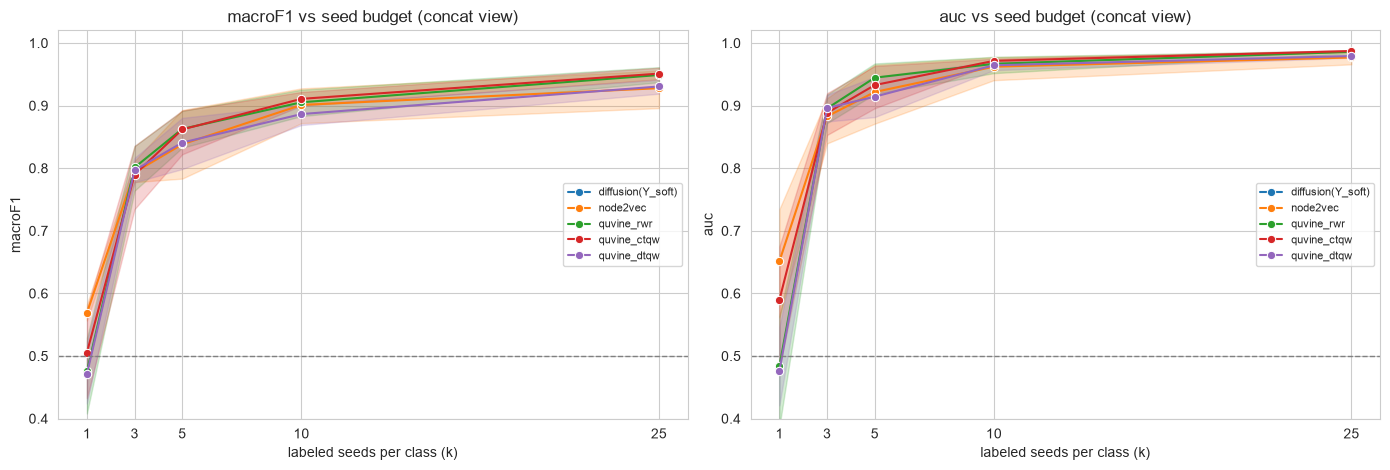

In [5]:
order = ["diffusion(Y_soft)"] + METHODS
view_show = "concat" if "concat" in ALL_VIEWS else VIEWS[0]
palette = dict(zip(order, sns.color_palette("tab10", len(order))))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, metric in zip(axes, ["macroF1", "auc"]):
    sub = clf_df[(clf_df["view"] == view_show) & (clf_df["method"].isin(order))]
    sns.lineplot(data=sub, x="k_seeds", y=metric, hue="method", hue_order=order,
                 marker="o", errorbar=("ci", 95), palette=palette, ax=ax)
    ax.set_title(f"{metric} vs seed budget ({view_show} view)")
    ax.set_xlabel("labeled seeds per class (k)"); ax.set_ylim(0.4, 1.02)
    ax.set_xticks(SEEDS_PER_CLASS)
    ax.axhline(0.5, ls="--", color="grey", lw=1)
    ax.legend(fontsize=8, title=None)
plt.tight_layout(); plt.show()

## 5. Node ranking (centroid seed → target) — the headline

For each class we build the **seed centroid** from just `k` labeled seeds, rank all non-seed
nodes by cosine similarity to it, and measure recovery of the **same-class eval nodes** with
recall@K / precision@K — sweeping `k` (the "centroid seed" budget). `SeedTargetEvaluator` also
computes **degree-matched** and **distance-matched** null targets: the honest controls that
separate "the walk found biology" from "the walk found hubs / nearby nodes".

This is where a good embedding earns its keep: with `k=1` the centroid is a single noisy anchor,
so recall depends almost entirely on how well the embedding places same-class cells together.

In [6]:
def rank_eval_fewshot(Z, view_graph, cls, seed_idx_cls, k_values, n_repeats):
    """Centroid-rank recovery of same-class eval nodes from a few-shot seed subset."""
    seed_c = [IDS[i] for i in seed_idx_cls]
    tgt_c  = [IDS[i] for i in np.where(eval_m & (y == cls))[0]]
    if not seed_c or not tgt_c:
        return None
    scores = np.asarray(seed_centroid_scores(Z, list(seed_idx_cls)), dtype=float)
    ev = SeedTargetEvaluator(view_graph, seeds=seed_c, targets=tgt_c, nodes=IDS)
    return ev.evaluate(scores, k_values=k_values, n_repeats=n_repeats)

rrows = []
if EVAL_MODE in ("ranking", "both"):
    for (method, view, seed), Z in EMB.items():
        gview = GRAPHS[VIEWS[0]] if view == "concat" else GRAPHS[view]  # concat: structure from 1st view
        for k in SEEDS_PER_CLASS:
            for sub in range(N_SUBSAMPLE):
                rng = np.random.default_rng(7 * (1000 * k + sub))
                for cls, cname in enumerate(CLASS_ORDER):
                    sidx = rng.choice(seed_pool[cls], size=k, replace=False)  # k seeds of this class
                    res = rank_eval_fewshot(Z, gview, cls, sidx, K_VALUES, n_repeats=5)
                    if res is None:
                        continue
                    for K in K_VALUES:
                        rrows.append({"method": method, "view": view, "emb_seed": seed,
                                      "k_seeds": k, "sub": sub, "class": cname, "K": K,
                                      "recall_true": res["true"]["recall"][K],
                                      "recall_degctrl": res["degree_matched"]["recall"][K][0],
                                      "recall_distctrl": res["distance_matched"]["recall"][K][0]})
    rank_df = pd.DataFrame(rrows)
    print(f"Ranking recall@{K_HEADLINE} — mean over draws, emb seeds & classes (concat), by k seeds/class:")
    show = (rank_df[(rank_df.K == K_HEADLINE) & (rank_df.view == "concat")]
            .groupby(["method", "k_seeds"])[["recall_true", "recall_degctrl", "recall_distctrl"]]
            .mean().round(3))
    display(show)
else:
    rank_df = pd.DataFrame()
    print("Ranking skipped (EVAL_MODE=%r)" % EVAL_MODE)

Ranking recall@50 — mean over draws, emb seeds & classes (concat), by k seeds/class:


recall_true  recall_degctrl  recall_distctrl
method      k_seeds                                              
node2vec    1              0.187           0.053            0.068
            3              0.194           0.050            0.097
            5              0.194           0.043            0.095
            10             0.210           0.042            0.068
            25             0.215           0.037            0.075
quvine_ctqw 1              0.162           0.066            0.084
            3              0.203           0.043            0.084
            5              0.199           0.043            0.083
            10             0.198           0.050            0.076
            25             0.213           0.042            0.080
quvine_dtqw 1              0.155           0.069            0.082
            3              0.199           0.047            0.087
            5              0.201           0.043            0.078
            10             0.207           0.045            0.070
            25             0.221           0.037            0.067
quvine_rwr  1              0.168           0.064            0.078
            3              0.191           0.048            0.100
            5              0.198           0.044            0.084
            10             0.200           0.050            0.077
            25             0.220           0.036            0.071

### 5a. Ranking — recall@K vs seed budget, against the null control (concat view)

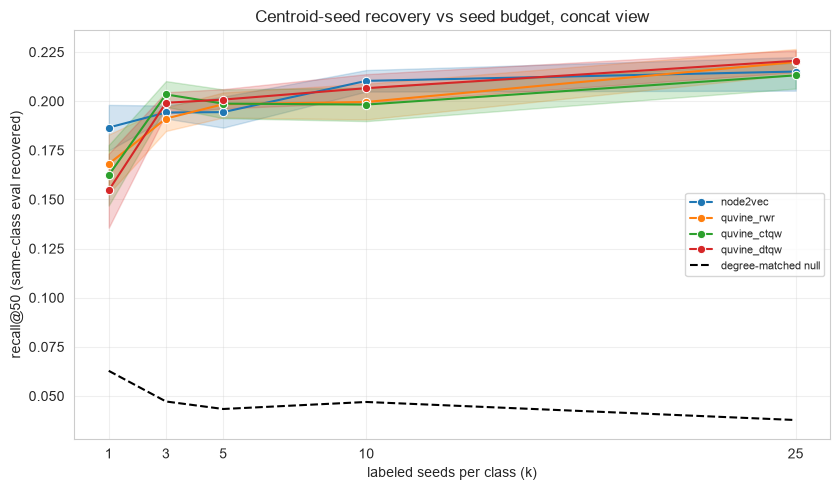

In [7]:
if not rank_df.empty:
    view_show = "concat" if "concat" in ALL_VIEWS else VIEWS[0]
    d = rank_df[(rank_df["view"] == view_show) & (rank_df["K"] == K_HEADLINE)]
    fig, ax = plt.subplots(figsize=(8.5, 5))
    palette = dict(zip(METHODS, sns.color_palette("tab10", len(METHODS))))
    sns.lineplot(data=d, x="k_seeds", y="recall_true", hue="method", hue_order=METHODS,
                 marker="o", errorbar=("ci", 95), palette=palette, ax=ax)
    # shared degree-matched null band, averaged over methods
    ctrl = d.groupby("k_seeds")["recall_degctrl"].mean()
    ax.plot(ctrl.index, ctrl.values, "k--", label="degree-matched null")
    ax.set_xlabel("labeled seeds per class (k)")
    ax.set_ylabel(f"recall@{K_HEADLINE} (same-class eval recovered)")
    ax.set_xticks(SEEDS_PER_CLASS)
    ax.set_title(f"Centroid-seed recovery vs seed budget, {view_show} view")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 6. Graph complexity lens

A quick spectral read on each view graph: the **normalized-Laplacian spectral gap** (algebraic
connectivity — small = slow-mixing / strongly clustered) and **greedy modularity**. The
heat-kernel-as-low-pass view predicts that slow-mixing, high-modularity graphs benefit most
from diffusion/quantum-walk smoothing — useful context for why one view may embed better.

In [8]:
import scipy.sparse.linalg as sla
from networkx.algorithms.community import greedy_modularity_communities, modularity as nx_mod

def spectral_gap_modularity(G):
    L = nx.normalized_laplacian_matrix(G).astype(float)
    try:
        ev = np.sort(sla.eigsh(L, k=4, which="SM", return_eigenvectors=False))
        pos = ev[ev > 1e-9]; lam2 = float(pos[0]) if len(pos) else float(ev[1])
    except Exception:
        lam2 = float("nan")
    mod = float(nx_mod(G, list(greedy_modularity_communities(G))))
    return lam2, mod

k_max = max(SEEDS_PER_CLASS)
comp = []
for v in VIEWS:
    lam2, mod = spectral_gap_modularity(GRAPHS[v])
    sel = clf_df[(clf_df.view == v) & (clf_df.method.isin(METHODS)) & (clf_df.k_seeds == k_max)]
    best = sel["macroF1"].max()
    comp.append({"view": v, "spectral_gap": round(lam2, 4), "modularity": round(mod, 3),
                 f"best_embed_macroF1@k={k_max}": round(best, 3)})
pd.DataFrame(comp)

,view,spectral_gap,modularity,best_embed_macroF1@k=25
0,rna,0.0051,0.580,0.880
1,protein,0.0325,0.549,0.927


## 7. Quantum vs classical — advantage & which complexity features drive it

Same idea as the QProfiler notebook, adapted to graphs, with a fair setup and two honest twists.

**Fair comparison.** Two things must be right for this to mean anything:
(1) **Enough walk budget** — with `QUICK=True`'s tiny params the quantum walks have too few
*steps* to develop their structural spread, which sandbags them; we run `QUICK=False` (full
params) applied **equally** to every method. (2) **The right baseline** — `node2vec` is the
**pure classical** yardstick, while `quvine_rwr` is *QuVINE's own pipeline on a classical walk*,
i.e. a hybrid **ablation**, not "the classical baseline." So the headline contrast is
**quantum walks (`quvine_ctqw`/`quvine_dtqw`) vs `node2vec`**, with `quvine_rwr` reported
separately as the same-pipeline control.

**A. Is there a quantum-walk advantage?** Classification (§4) is close to saturated, so the
**ranking** task (§5, recall@K) is where any advantage shows. We take the per-unit advantage
`Δrecall = recall(quantum) − recall(baseline)` across each `(view, emb_seed, sub, class)`
pairing unit and summarize it as a **paired Cohen's *d_z*** — *stratified by the few-shot seed
budget `k`*, because the thesis is that the quantum walk's structural spread should help most at
**small `k`** (a noisy one-anchor centroid). A paired two-group contrast is exactly where
Cohen's *d* is the right tool.

**B. Which graph-complexity feature tracks that advantage?** Graph complexity (§6) only varies
*per view* — 2–3 points — far too few to correlate. To get real statistical support we run a
**node-subsample bootstrap**: repeatedly keep a random 70 % of cells, and for each subsample
recompute (i) a panel of graph-complexity features on the induced subgraph and (ii) the
quantum-vs-`node2vec` ranking advantage **from the already-computed, fixed node embeddings**
(no re-embedding). Correlating the features against the advantage across subsamples points to
*which complexity properties favour the quantum walk*.

> Honest caveat: even with a fair budget, a quantum edge is not guaranteed in every regime —
> e.g. at `k=1` a single noisy anchor can favour the classical embedding. We report each seed
> budget separately and explain the mechanism rather than hiding the unfavourable rows.
> Bootstrap CIs are also optimistic (subsamples overlap), so Part B flags *candidate* drivers;
> a *panel of distinct graphs* remains the gold standard.

HEADLINE — quantum walks (ctqw+dtqw) vs PURE classical node2vec, recall@50
(+) d_z => quantum recovers more same-class targets at that seed budget.


,vs,stratum,mean_dRecall,cohens_dz,ci_low,ci_high,p,n
0,node2vec (classical),k=1,-0.017,-0.603,-0.893,-0.313,0.000,54
1,node2vec (classical),k=3,0.005,0.400,0.123,0.677,0.005,54
2,node2vec (classical),k=5,0.001,0.065,-0.202,0.332,0.636,54
3,node2vec (classical),k=10,-0.005,-0.413,-0.691,-0.135,0.004,54
4,node2vec (classical),k=25,0.003,0.206,-0.064,0.475,0.137,54
5,node2vec (classical),overall,-0.003,-0.133,-0.253,-0.013,0.030,270


ABLATION — quantum walks vs quvine_rwr (QuVINE pipeline, classical walk):


,vs,stratum,mean_dRecall,cohens_dz,ci_low,ci_high,p,n
0,quvine_rwr (ablation),k=1,-0.008,-0.413,-0.690,-0.135,0.004,54
1,quvine_rwr (ablation),k=3,0.003,0.183,-0.086,0.452,0.183,54
2,quvine_rwr (ablation),k=5,0.003,0.138,-0.130,0.406,0.316,54
3,quvine_rwr (ablation),k=10,0.001,0.082,-0.185,0.349,0.548,54
4,quvine_rwr (ablation),k=25,-0.000,-0.028,-0.295,0.239,0.837,54
5,quvine_rwr (ablation),overall,-0.000,-0.017,-0.136,0.102,0.782,270


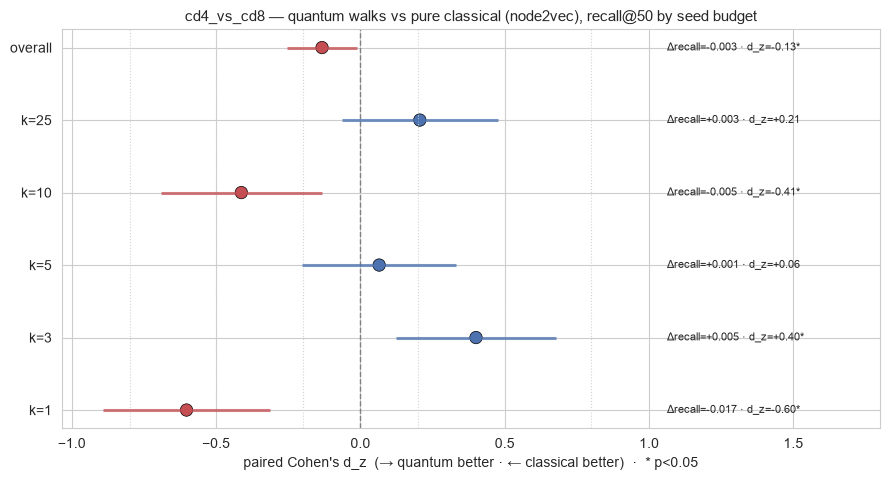

In [9]:
# ============================================================================
# Part A — Quantum vs classical on the RANKING task (headroom), paired Cohen's d_z
#   quantum   = quvine_ctqw + quvine_dtqw
#   HEADLINE baseline = node2vec  (pure classical)      ABLATION = quvine_rwr (QuVINE, classical walk)
#   metric    = recall_true @ K_HEADLINE                contrast axis = few-shot seed budget k
# ============================================================================
from scipy import stats

QUANTUM_M   = ["quvine_ctqw", "quvine_dtqw"]   # quantum walks
CLASSICAL_M = ["node2vec"]                      # PURE classical baseline (headline contrast)
ABLATION_M  = ["quvine_rwr"]                    # QuVINE pipeline w/ classical walk (control)

def dz_ci(delta):
    d = np.asarray(delta, float); nn = len(d)
    m, sd = d.mean(), d.std(ddof=1)
    dz = m / sd if sd > 1e-12 else 0.0
    se = np.sqrt(1 / nn + dz ** 2 / (2 * nn))
    p  = stats.ttest_1samp(d, 0).pvalue if sd > 1e-12 else np.nan
    return dict(mean_dRecall=m, cohens_dz=dz, ci_low=dz - 1.96 * se,
                ci_high=dz + 1.96 * se, p=p, n=nn)

def advantage_table(baseline_methods, label):
    """Paired quantum-vs-baseline advantage on recall@K_HEADLINE, by few-shot k budget."""
    rd = rank_df[rank_df["K"] == K_HEADLINE].copy()
    rd = rd[rd["method"].isin(QUANTUM_M + baseline_methods)]
    rd["arm"] = np.where(rd["method"].isin(QUANTUM_M), "quantum", "base")
    piv = (rd.groupby(["view", "emb_seed", "k_seeds", "sub", "class", "arm"])["recall_true"]
             .mean().unstack("arm"))
    piv["delta"] = piv["quantum"] - piv["base"]          # quantum advantage per unit
    piv = piv.dropna(subset=["delta"]).reset_index()
    rows = [{"stratum": f"k={k}", **dz_ci(piv.loc[piv["k_seeds"] == k, "delta"])}
            for k in sorted(piv["k_seeds"].unique())]
    rows.append({"stratum": "overall", **dz_ci(piv["delta"])})
    t = pd.DataFrame(rows); t.insert(0, "vs", label)
    return t

advQ  = advantage_table(CLASSICAL_M, "node2vec (classical)")   # headline
advAb = advantage_table(ABLATION_M,  "quvine_rwr (ablation)")  # control

print(f"HEADLINE — quantum walks (ctqw+dtqw) vs PURE classical node2vec, recall@{K_HEADLINE}")
print("(+) d_z => quantum recovers more same-class targets at that seed budget.")
display(advQ.round(3))
print("ABLATION — quantum walks vs quvine_rwr (QuVINE pipeline, classical walk):")
display(advAb.round(3))

# ---- forest plot: quantum advantage over the PURE classical baseline, by seed budget ----
yv   = np.arange(len(advQ))
cols = ["#4c72b0" if d >= 0 else "#c44e52" for d in advQ["cohens_dz"]]
xr   = float(np.nanmax([advQ["ci_high"].abs().max(), advQ["ci_low"].abs().max(), 0.9]))
fig, ax = plt.subplots(figsize=(9, 0.55 * len(advQ) + 1.6))
for xb in (0.2, 0.5, 0.8):
    for s in (-1, 1):
        ax.axvline(s * xb, color="lightgrey", ls=":", lw=0.8)
ax.axvline(0, color="grey", ls="--", lw=1)
ax.hlines(yv, advQ["ci_low"], advQ["ci_high"], color=cols, lw=2.2, alpha=0.75)
ax.scatter(advQ["cohens_dz"], yv, s=80, color=cols, edgecolor="k", linewidth=0.5)
for yi, r in zip(yv, advQ.itertuples()):
    star = "*" if (r.p == r.p and r.p < 0.05) else ""
    ax.text(xr * 1.18, yi, f"Δrecall={r.mean_dRecall:+.3f} · d_z={r.cohens_dz:+.2f}{star}",
            va="center", fontsize=8)
ax.set_yticks(yv); ax.set_yticklabels(advQ["stratum"])
ax.set_xlim(-xr * 1.15, xr * 2.0)
ax.set_xlabel("paired Cohen's d_z  (→ quantum better · ← classical better)  ·  * p<0.05")
ax.set_title(f"cd4_vs_cd8 — quantum walks vs pure classical (node2vec), recall@{K_HEADLINE} by seed budget",
             fontsize=11)
plt.tight_layout(); plt.show()

bootstrap rows: 80  (B=40 x 2 views)  |  recall@50
quantum_adv = recall(ctqw,dtqw) − recall(node2vec), avg over classes & 3 emb-seeds


,feature,spearman_r,p,n,absr
0,modularity,0.592,0.0,80,0.592
1,degree_heterog,-0.664,0.0,80,0.664
2,spectral_gap,-0.699,0.0,80,0.699
3,edge_density,-0.713,0.0,80,0.713
4,mean_degree,-0.713,0.0,80,0.713
5,assortativity,0.734,0.0,80,0.734
6,transitivity,0.752,0.0,80,0.752
7,avg_clustering,0.757,0.0,80,0.757


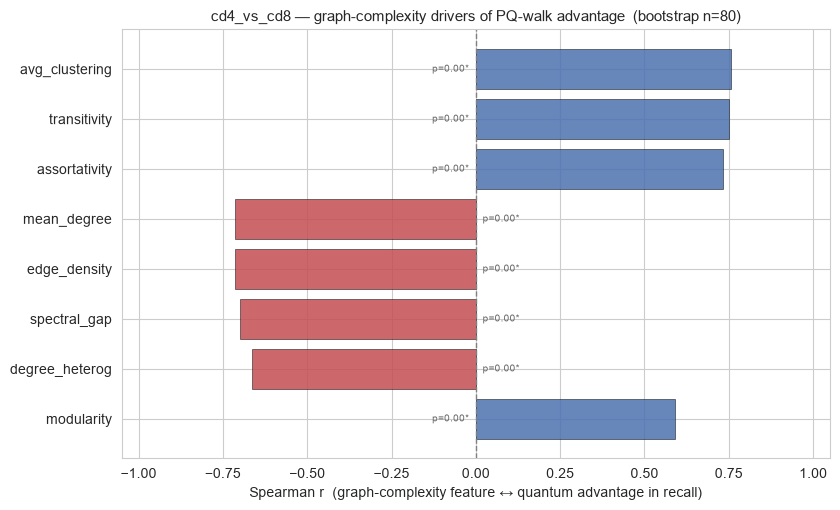

In [10]:
# ============================================================================
# Part B — Which GRAPH-complexity feature tracks the quantum advantage?
# Node-subsample bootstrap: embeddings are per-node & FIXED, so per subsample we
# recompute (i) graph-complexity on the induced subgraph and (ii) quantum/classical
# ranking recall from the existing embeddings -- no re-embedding -> real n.
# quantum advantage = recall(ctqw,dtqw) − recall(node2vec)   [pure classical baseline]
# ============================================================================
import scipy.sparse.linalg as sla
from networkx.algorithms.community import greedy_modularity_communities, modularity as nx_mod
from scipy.stats import spearmanr

B, FRAC, K_B = 40, 0.7, K_HEADLINE
idx_all = np.arange(N)

def graph_complexity(G):
    """Panel of graph-complexity features on an induced subgraph (None if too small)."""
    if G.number_of_nodes() < 20 or G.number_of_edges() < 5:
        return None
    f  = {}
    Gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    try:
        L  = nx.normalized_laplacian_matrix(Gc).astype(float)
        ev = np.sort(sla.eigsh(L, k=min(4, Gc.number_of_nodes() - 1), which="SM",
                               return_eigenvectors=False))
        pos = ev[ev > 1e-9]; f["spectral_gap"] = float(pos[0]) if len(pos) else np.nan
    except Exception:
        f["spectral_gap"] = np.nan
    try:
        f["modularity"] = float(nx_mod(G, list(greedy_modularity_communities(G))))
    except Exception:
        f["modularity"] = np.nan
    f["avg_clustering"] = nx.average_clustering(G)
    f["transitivity"]   = nx.transitivity(G)
    try:
        f["assortativity"] = nx.degree_assortativity_coefficient(G)
    except Exception:
        f["assortativity"] = np.nan
    f["edge_density"]   = nx.density(G)
    degs = np.array([d for _, d in G.degree()], float)
    f["mean_degree"]    = degs.mean()
    f["degree_heterog"] = degs.std() / degs.mean() if degs.mean() > 0 else np.nan
    return f

def _recall_at_k(scores, cand, targets, k):
    if len(cand) == 0 or len(targets) == 0:
        return np.nan
    top = cand[np.argsort(-scores[cand])[:k]]
    return len(set(top.tolist()) & set(targets.tolist())) / len(targets)

def _method_recall(method, view, S_mask, k):
    """mean recall@k over classes & embedding seeds for one method on subsample S."""
    vals = []
    for cls in range(len(CLASS_ORDER)):
        seed_c = np.where(S_mask & seed_m & (y == cls))[0]
        tgt_c  = np.where(S_mask & eval_m & (y == cls))[0]
        cand   = np.where(S_mask & ~seed_m)[0]
        if len(seed_c) < 1 or len(tgt_c) < 1:
            return np.nan
        for sd in range(N_REPEATS):
            scores = np.asarray(seed_centroid_scores(EMB[(method, view, sd)], list(seed_c)), float)
            vals.append(_recall_at_k(scores, cand, tgt_c, k))
    return np.nanmean(vals) if vals else np.nan

rng   = np.random.default_rng(20240517)
brows = []
for b in range(B):
    keep   = rng.choice(idx_all, size=int(FRAC * N), replace=False)
    S_mask = np.zeros(N, bool); S_mask[keep] = True
    keep_ids = [IDS[i] for i in keep]
    for view in VIEWS:                                   # rna, protein (concat has no own graph)
        cf = graph_complexity(GRAPHS[view].subgraph(keep_ids).copy())
        if cf is None:
            continue
        qr = np.nanmean([_method_recall(m, view, S_mask, K_B) for m in QUANTUM_M])
        cr = np.nanmean([_method_recall(m, view, S_mask, K_B) for m in CLASSICAL_M])  # node2vec
        if np.isnan(qr) or np.isnan(cr):
            continue
        brows.append({"b": b, "view": view, "quantum_adv": qr - cr, **cf})

boot = pd.DataFrame(brows)
FEATURES = ["spectral_gap", "modularity", "avg_clustering", "transitivity",
            "assortativity", "edge_density", "mean_degree", "degree_heterog"]
crows = []
for feat in FEATURES:
    d = boot[[feat, "quantum_adv"]].dropna()
    if d[feat].nunique() > 2 and len(d) >= 5:
        r, p = spearmanr(d[feat], d["quantum_adv"])
        crows.append({"feature": feat, "spearman_r": r, "p": p, "n": len(d)})
corr = (pd.DataFrame(crows).assign(absr=lambda t: t["spearman_r"].abs())
        .sort_values("absr").reset_index(drop=True))
print(f"bootstrap rows: {len(boot)}  (B={B} x {len(VIEWS)} views)  |  recall@{K_B}")
print(f"quantum_adv = recall(ctqw,dtqw) − recall(node2vec), avg over classes & {N_REPEATS} emb-seeds")
display(corr.round(3))

# ---- plot: complexity feature vs quantum advantage (bootstrap correlation) -----
yb   = np.arange(len(corr))
vals = corr["spearman_r"].to_numpy()
cols = ["#4c72b0" if v >= 0 else "#c44e52" for v in vals]
fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(corr) + 1.6))
ax.axvline(0, color="grey", ls="--", lw=1)
ax.barh(yb, vals, color=cols, edgecolor="k", linewidth=0.4, alpha=0.85)
for yi, r in zip(yb, corr.itertuples()):
    star = "*" if (r.p == r.p and r.p < 0.05) else ""
    ax.text((0.02 if r.spearman_r < 0 else -0.02), yi, f"p={r.p:.2f}{star}",
            va="center", ha="left" if r.spearman_r < 0 else "right",
            fontsize=7.5, color="dimgray")
ax.set_yticks(yb); ax.set_yticklabels(corr["feature"]); ax.set_xlim(-1.05, 1.05)
ax.set_xlabel("Spearman r  (graph-complexity feature ↔ quantum advantage in recall)")
ax.set_title(f"cd4_vs_cd8 — graph-complexity drivers of PQ-walk advantage  (bootstrap n={len(boot)})",
             fontsize=11)
plt.tight_layout(); plt.show()

## 8. How to read this

- **Quantum vs classical (§7) is the verdict.** Part A asks *whether* the quantum walks beat
  the **pure classical baseline `node2vec`** on ranking recall (paired Cohen's *d_z*, stratified
  by seed budget — watch the small-`k` rows), with `quvine_rwr` shown separately as the
  same-pipeline **ablation**; Part B asks *which graph-complexity feature* the quantum edge
  tracks, via a node-subsample bootstrap. Positive `d_z` = quantum better; bootstrap bars whose
  CIs clear 0 flag candidate drivers.
- **Ranking (§5) is the headline.** With a few-shot **centroid seed**, recall@K that stays
  **above the degree/distance-matched nulls** means the embedding recovers same-class cells for
  real structural reasons, not by preferring hubs or near neighbors. Watch the **small-`k` end**
  of the curve: at `k=1` the centroid is one noisy anchor, so any separation between the
  quantum walks (`quvine_ctqw`/`quvine_dtqw`) and the pure classical `node2vec` (with
  `quvine_rwr` as the same-pipeline ablation) is the quantum walk's structural spread doing the
  work. Overlapping 95% CIs = no reproducible difference at this scale.
- **Classification (§4)** is the sanity/counterpoint arm: does the LR-on-embeddings advantage
  (or the no-embedding `diffusion(Y_soft)` baseline) survive when the label budget is tiny? On
  the old T-vs-mono task every curve pinned at ~1.0; on CD4-vs-CD8 the small-`k` regime should
  spread them out.
- **Complexity (§6)** contextualizes which view the diffusion should help on (slow-mixing,
  high-modularity graphs benefit most from diffusion/quantum-walk smoothing).

**To go further:** `QUICK=True` gives a fast (but quantum-sandbagging) laptop run; raise
`N_REPEATS` / `N_SUBSAMPLE` for tighter CIs; extend `SEEDS_PER_CLASS` toward the full pool to
see where the curves converge; swap `TASK` to `binary_lymphoid_vs_myeloid` (intermediate
difficulty) or add registry methods (`gat_ctqw_heat`, `graphgps_dtqw_poly`, `filter_ctqw_heat`,
…) to `METHODS` (GAT/GraphGPS train a small net — slower). This tutorial is scoped to the harder
**cd4_vs_cd8** vehicle precisely because T-vs-mono saturated; the other `pbmc5k_small_*` graph
files share the same layout and can be dropped in via `TASK` + `H5AD`.